# Notebook 01 — Model Evaluation & Hyperparameter Tuning

This notebook evaluates all four ranking models (TF-IDF, BM25, QLM-JM, QLM-Dirichlet) on the Cranfield collection, performs grid-search hyperparameter tuning, and saves results.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from core.indexer import load_cranfield, build_inverted_index, preprocess
from core.models import rank
from core.metrics import (
    precision_at_k, recall_at_k, f1_at_k,
    average_precision, mean_average_precision, mean_reciprocal_rank,
    evaluate_all
)

# Create results directory
RESULTS_DIR = os.path.abspath(os.path.join('..', 'results'))
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')

Results will be saved to: D:\neit_ng\prjs_i\py_cmm_4thy2nds\ir_thuchanh\ir_prj\results


## 1. Load Data & Build Index

In [2]:
docs, queries, qrels = load_cranfield()
inverted_index, doc_lengths, avg_dl, N, tf_raw, vocabulary = build_inverted_index(docs)

print(f'Documents: {len(docs)}')
print(f'Queries:   {len(queries)}')
print(f'Qrels:     {len(qrels)}')
print(f'Vocabulary (stemmed): {len(inverted_index)} terms')
print(f'Avg document length:  {avg_dl:.1f} tokens')

Documents: 1400
Queries:   225
Qrels:     225
Vocabulary (stemmed): 4709 terms
Avg document length:  102.9 tokens


## 2. Evaluate All Models with Default Parameters

In [3]:
K = 10  # Evaluation cutoff
TOP_K_RETRIEVE = 100  # Retrieve more for MAP/MRR computation

model_configs = {
    'TF-IDF': {},
    'BM25': {'k1': 1.2, 'b': 0.75},
    'QLM (JM)': {'lam': 0.4},
    'QLM (Dirichlet)': {'mu': 1500.0},
}

all_metrics = {}

for model_name, params in model_configs.items():
    t0 = time.time()
    results = {}
    for qid, qtext in queries.items():
        q_tokens = preprocess(qtext)
        ranked = rank(model_name, q_tokens, inverted_index, tf_raw,
                      doc_lengths, avg_dl, N, top_k=TOP_K_RETRIEVE, **params)
        results[qid] = [doc_id for doc_id, _ in ranked]
    elapsed = time.time() - t0
    
    metrics = evaluate_all(results, qrels, k=K)
    metrics['Time (s)'] = round(elapsed, 3)
    all_metrics[model_name] = metrics
    print(f'{model_name:20s} | MAP={metrics["MAP"]:.4f} | MRR={metrics["MRR"]:.4f} | '
          f'P@{K}={metrics[f"P@{K}"]:.4f} | R@{K}={metrics[f"R@{K}"]:.4f} | '
          f'F1@{K}={metrics[f"F1@{K}"]:.4f} | {elapsed:.2f}s')

TF-IDF               | MAP=0.4097 | MRR=0.8061 | P@10=0.3053 | R@10=0.4487 | F1@10=0.3368 | 0.14s


BM25                 | MAP=0.4260 | MRR=0.8170 | P@10=0.3133 | R@10=0.4527 | F1@10=0.3433 | 0.15s


QLM (JM)             | MAP=0.4055 | MRR=0.8168 | P@10=0.3000 | R@10=0.4378 | F1@10=0.3299 | 0.54s


QLM (Dirichlet)      | MAP=0.3791 | MRR=0.7594 | P@10=0.2822 | R@10=0.4183 | F1@10=0.3127 | 0.54s


In [4]:
# Save baseline metrics
with open(os.path.join(RESULTS_DIR, 'baseline_metrics.json'), 'w') as f:
    json.dump(all_metrics, f, indent=2)
print('Saved baseline_metrics.json')

Saved baseline_metrics.json


## 3. Comparison Bar Charts

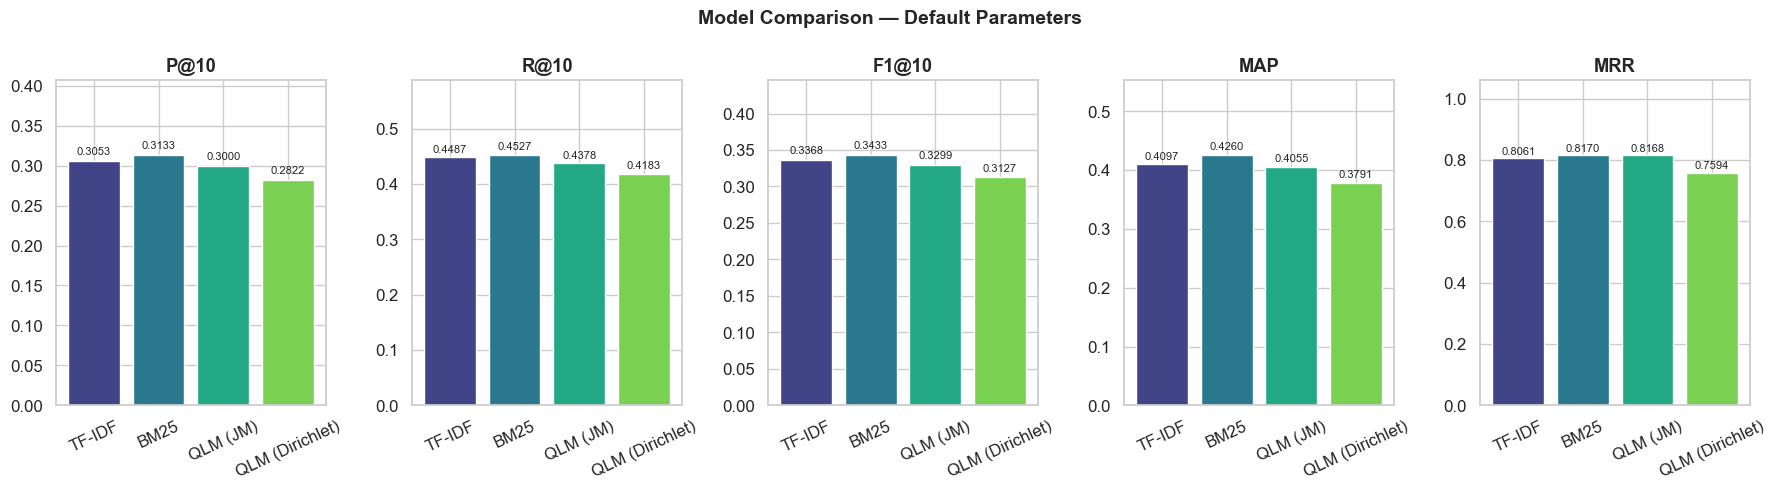

Saved model_comparison.png


In [5]:
sns.set_theme(style='whitegrid', font_scale=1.1)
models = list(all_metrics.keys())
metric_names = [f'P@{K}', f'R@{K}', f'F1@{K}', 'MAP', 'MRR']

fig, axes = plt.subplots(1, len(metric_names), figsize=(18, 5), sharey=False)
colors = sns.color_palette('viridis', len(models))

for ax, mn in zip(axes, metric_names):
    vals = [all_metrics[m][mn] for m in models]
    bars = ax.bar(models, vals, color=colors)
    ax.set_title(mn, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', rotation=25)

fig.suptitle('Model Comparison — Default Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved model_comparison.png')

## 4. Hyperparameter Tuning — BM25 (k1, b)

In [6]:
k1_values = [0.5, 0.75, 1.0, 1.2, 1.5, 2.0]
b_values = [0.25, 0.5, 0.75, 1.0]

bm25_grid = np.zeros((len(k1_values), len(b_values)))
best_bm25_map = -1
best_bm25_params = {}

print('Tuning BM25...')
for i, k1 in enumerate(k1_values):
    for j, b in enumerate(b_values):
        results = {}
        for qid, qtext in queries.items():
            q_tokens = preprocess(qtext)
            ranked = rank('BM25', q_tokens, inverted_index, tf_raw,
                          doc_lengths, avg_dl, N, top_k=TOP_K_RETRIEVE, k1=k1, b=b)
            results[qid] = [doc_id for doc_id, _ in ranked]
        m = mean_average_precision(results, qrels)
        bm25_grid[i, j] = m
        if m > best_bm25_map:
            best_bm25_map = m
            best_bm25_params = {'k1': k1, 'b': b, 'MAP': m}
        print(f'  k1={k1:.2f}, b={b:.2f} => MAP={m:.4f}')

print(f'\nBest BM25: k1={best_bm25_params["k1"]}, b={best_bm25_params["b"]}, MAP={best_bm25_params["MAP"]:.4f}')

Tuning BM25...
  k1=0.50, b=0.25 => MAP=0.3849


  k1=0.50, b=0.50 => MAP=0.3955
  k1=0.50, b=0.75 => MAP=0.4029


  k1=0.50, b=1.00 => MAP=0.4081
  k1=0.75, b=0.25 => MAP=0.3944


  k1=0.75, b=0.50 => MAP=0.4082
  k1=0.75, b=0.75 => MAP=0.4146


  k1=0.75, b=1.00 => MAP=0.4181
  k1=1.00, b=0.25 => MAP=0.4022


...

  k1=1.20, b=1.00 => MAP=0.4242
  k1=1.50, b=0.25 => MAP=0.4112


  k1=1.50, b=0.50 => MAP=0.4247
  k1=1.50, b=0.75 => MAP=0.4305


  k1=1.50, b=1.00 => MAP=0.4268
  k1=2.00, b=0.25 => MAP=0.4156


  k1=2.00, b=0.50 => MAP=0.4276
  k1=2.00, b=0.75 => MAP=0.4330


  k1=2.00, b=1.00 => MAP=0.4294

Best BM25: k1=2.0, b=0.75, MAP=0.4330


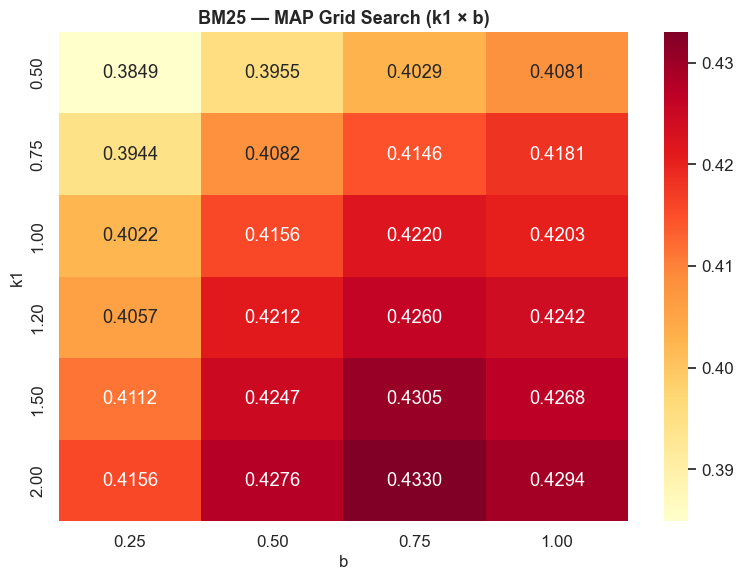

Saved bm25_heatmap.png


In [7]:
# BM25 Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(bm25_grid, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=[f'{b:.2f}' for b in b_values],
            yticklabels=[f'{k1:.2f}' for k1 in k1_values], ax=ax)
ax.set_xlabel('b', fontsize=12)
ax.set_ylabel('k1', fontsize=12)
ax.set_title('BM25 — MAP Grid Search (k1 × b)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'bm25_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved bm25_heatmap.png')

## 5. Hyperparameter Tuning — QLM Jelinek-Mercer (λ)

In [8]:
lam_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
jm_maps = []
best_jm_map = -1
best_jm_lam = None

print('Tuning QLM Jelinek-Mercer...')
for lam in lam_values:
    results = {}
    for qid, qtext in queries.items():
        q_tokens = preprocess(qtext)
        ranked = rank('QLM (JM)', q_tokens, inverted_index, tf_raw,
                      doc_lengths, avg_dl, N, top_k=TOP_K_RETRIEVE, lam=lam)
        results[qid] = [doc_id for doc_id, _ in ranked]
    m = mean_average_precision(results, qrels)
    jm_maps.append(m)
    if m > best_jm_map:
        best_jm_map = m
        best_jm_lam = lam
    print(f'  λ={lam:.1f} => MAP={m:.4f}')

print(f'\nBest QLM-JM: λ={best_jm_lam}, MAP={best_jm_map:.4f}')

Tuning QLM Jelinek-Mercer...


  λ=0.1 => MAP=0.3939


  λ=0.2 => MAP=0.4023


  λ=0.3 => MAP=0.4061


  λ=0.4 => MAP=0.4055


  λ=0.5 => MAP=0.4039


  λ=0.6 => MAP=0.4022


  λ=0.7 => MAP=0.3972


  λ=0.8 => MAP=0.3923


  λ=0.9 => MAP=0.3828

Best QLM-JM: λ=0.3, MAP=0.4061


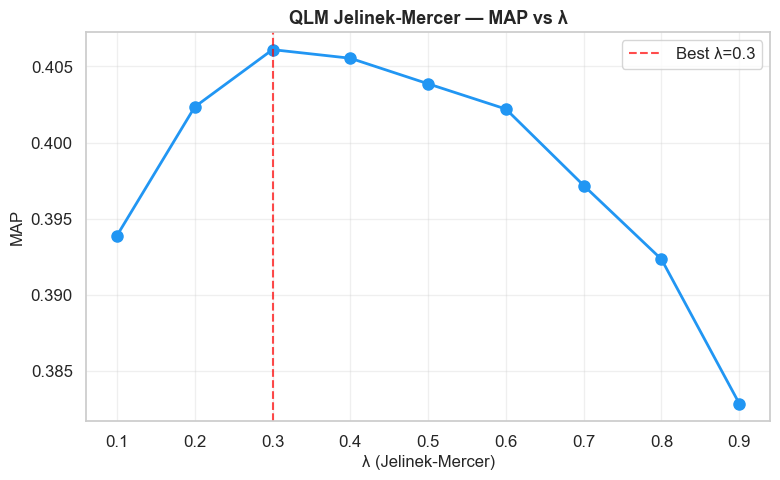

Saved qlm_jm_lambda.png


In [9]:
# QLM-JM: MAP vs λ
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lam_values, jm_maps, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.axvline(best_jm_lam, color='red', linestyle='--', alpha=0.7, label=f'Best λ={best_jm_lam}')
ax.set_xlabel('λ (Jelinek-Mercer)', fontsize=12)
ax.set_ylabel('MAP', fontsize=12)
ax.set_title('QLM Jelinek-Mercer — MAP vs λ', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'qlm_jm_lambda.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved qlm_jm_lambda.png')

## 6. Hyperparameter Tuning — QLM Dirichlet (μ)

In [10]:
mu_values = [100, 250, 500, 750, 1000, 1500, 2000, 3000]
dir_maps = []
best_dir_map = -1
best_dir_mu = None

print('Tuning QLM Dirichlet...')
for mu in mu_values:
    results = {}
    for qid, qtext in queries.items():
        q_tokens = preprocess(qtext)
        ranked = rank('QLM (Dirichlet)', q_tokens, inverted_index, tf_raw,
                      doc_lengths, avg_dl, N, top_k=TOP_K_RETRIEVE, mu=mu)
        results[qid] = [doc_id for doc_id, _ in ranked]
    m = mean_average_precision(results, qrels)
    dir_maps.append(m)
    if m > best_dir_map:
        best_dir_map = m
        best_dir_mu = mu
    print(f'  μ={mu:5d} => MAP={m:.4f}')

print(f'\nBest QLM-Dirichlet: μ={best_dir_mu}, MAP={best_dir_map:.4f}')

Tuning QLM Dirichlet...


  μ=  100 => MAP=0.4005


  μ=  250 => MAP=0.4064


  μ=  500 => MAP=0.3998


  μ=  750 => MAP=0.3943


  μ= 1000 => MAP=0.3882


  μ= 1500 => MAP=0.3791


  μ= 2000 => MAP=0.3706


  μ= 3000 => MAP=0.3633

Best QLM-Dirichlet: μ=250, MAP=0.4064


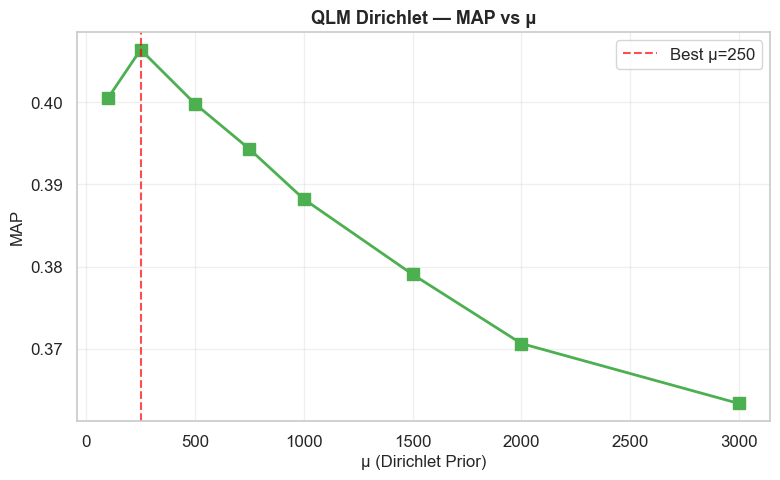

Saved qlm_dirichlet_mu.png


In [11]:
# QLM-Dirichlet: MAP vs μ
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mu_values, dir_maps, 's-', color='#4CAF50', linewidth=2, markersize=8)
ax.axvline(best_dir_mu, color='red', linestyle='--', alpha=0.7, label=f'Best μ={best_dir_mu}')
ax.set_xlabel('μ (Dirichlet Prior)', fontsize=12)
ax.set_ylabel('MAP', fontsize=12)
ax.set_title('QLM Dirichlet — MAP vs μ', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'qlm_dirichlet_mu.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved qlm_dirichlet_mu.png')

## 7. Re-evaluate with Optimal Parameters

In [12]:
best_params = {
    'BM25': {'k1': best_bm25_params['k1'], 'b': best_bm25_params['b']},
    'QLM (JM)': {'lam': best_jm_lam},
    'QLM (Dirichlet)': {'mu': float(best_dir_mu)},
}

# Save best params for Streamlit
with open(os.path.join(RESULTS_DIR, 'best_params.json'), 'w') as f:
    json.dump(best_params, f, indent=2)
print(f'Best params saved: {json.dumps(best_params, indent=2)}')

Best params saved: {
  "BM25": {
    "k1": 2.0,
    "b": 0.75
  },
  "QLM (JM)": {
    "lam": 0.3
  },
  "QLM (Dirichlet)": {
    "mu": 250.0
  }
}


In [13]:
# Re-run all models with optimal params
optimal_configs = {
    'TF-IDF': {},
    'BM25': best_params['BM25'],
    'QLM (JM)': best_params['QLM (JM)'],
    'QLM (Dirichlet)': best_params['QLM (Dirichlet)'],
}

optimal_metrics = {}
for model_name, params in optimal_configs.items():
    results = {}
    for qid, qtext in queries.items():
        q_tokens = preprocess(qtext)
        ranked = rank(model_name, q_tokens, inverted_index, tf_raw,
                      doc_lengths, avg_dl, N, top_k=TOP_K_RETRIEVE, **params)
        results[qid] = [doc_id for doc_id, _ in ranked]
    metrics = evaluate_all(results, qrels, k=K)
    optimal_metrics[model_name] = metrics
    print(f'{model_name:20s} | MAP={metrics["MAP"]:.4f} | MRR={metrics["MRR"]:.4f} | '
          f'P@{K}={metrics[f"P@{K}"]:.4f} | R@{K}={metrics[f"R@{K}"]:.4f} | '
          f'F1@{K}={metrics[f"F1@{K}"]:.4f}')

with open(os.path.join(RESULTS_DIR, 'optimal_metrics.json'), 'w') as f:
    json.dump(optimal_metrics, f, indent=2)
print('\nSaved optimal_metrics.json')

TF-IDF               | MAP=0.4097 | MRR=0.8061 | P@10=0.3053 | R@10=0.4487 | F1@10=0.3368


BM25                 | MAP=0.4330 | MRR=0.8292 | P@10=0.3191 | R@10=0.4573 | F1@10=0.3482


QLM (JM)             | MAP=0.4061 | MRR=0.8091 | P@10=0.2996 | R@10=0.4405 | F1@10=0.3306


QLM (Dirichlet)      | MAP=0.4064 | MRR=0.8075 | P@10=0.2991 | R@10=0.4359 | F1@10=0.3287

Saved optimal_metrics.json


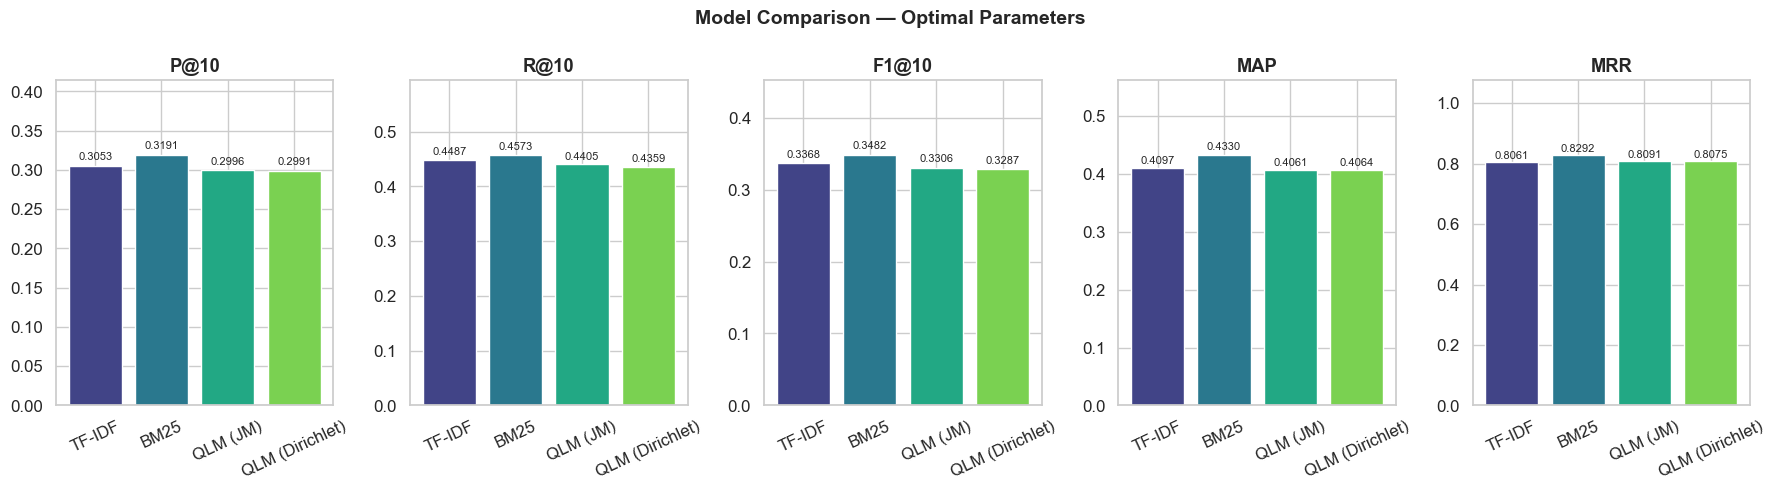

Saved model_comparison_optimal.png


In [14]:
# Final comparison bar chart with optimal params
fig, axes = plt.subplots(1, len(metric_names), figsize=(18, 5), sharey=False)
colors = sns.color_palette('viridis', len(models))

for ax, mn in zip(axes, metric_names):
    vals = [optimal_metrics[m][mn] for m in models]
    bars = ax.bar(models, vals, color=colors)
    ax.set_title(mn, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', rotation=25)

fig.suptitle('Model Comparison — Optimal Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'model_comparison_optimal.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved model_comparison_optimal.png')

## 8. Summary Table

In [15]:
from IPython.display import display
import pandas as pd

# Build a summary DataFrame
rows = []
for model_name in models:
    row = {'Model': model_name}
    for mn in metric_names:
        row[mn] = f"{optimal_metrics[model_name][mn]:.4f}"
    params_str = json.dumps(optimal_configs[model_name]) if optimal_configs[model_name] else '-'
    row['Best Params'] = params_str
    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(os.path.join(RESULTS_DIR, 'summary_table.csv'), index=False)
print('\nSaved summary_table.csv')

          Model   P@10   R@10  F1@10    MAP    MRR            Best Params
         TF-IDF 0.3053 0.4487 0.3368 0.4097 0.8061                      -
           BM25 0.3191 0.4573 0.3482 0.4330 0.8292 {"k1": 2.0, "b": 0.75}
       QLM (JM) 0.2996 0.4405 0.3306 0.4061 0.8091           {"lam": 0.3}
QLM (Dirichlet) 0.2991 0.4359 0.3287 0.4064 0.8075          {"mu": 250.0}

Saved summary_table.csv
